In [17]:
import sys
import os
from pathlib import Path

import pandas as pd
import numpy as np
import duckdb
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('..'))

from utilities import customdataloader

In [18]:
DATA_ROOT = Path(r"G:\My Drive\Data")


# Ajouter les nouveaux fichiers de 2024 aux anciens pour avoir des fichiers complets
prices_hist = pd.read_parquet(DATA_ROOT / "prices" / "prices.parquet")
prices_2024 = pd.read_parquet(DATA_ROOT / "prices" / "prices_2024.parquet")
prices_all = pd.concat([prices_hist, prices_2024], ignore_index=True)

costs_hist = pd.read_parquet(DATA_ROOT / "costs" / "costs.parquet")
costs_2024 = pd.read_parquet(DATA_ROOT / "costs" / "costs_2024.parquet")
costs_all = pd.concat([costs_hist, costs_2024], ignore_index=True)

prices_all.to_parquet(DATA_ROOT / "prices" / "prices_all.parquet", index=False)
costs_all.to_parquet(DATA_ROOT / "costs" / "costs_all.parquet", index=False)

loader = customdataloader(
    pricefile=str(DATA_ROOT / "prices" / "prices_all.parquet"),
    costfile=str(DATA_ROOT / "costs" / "costs_all.parquet"),
    dsimfile=[
        str(DATA_ROOT / "sim_daily" / f"sim_daily_{y}.parquet")
        for y in [2020, 2021, 2022, 2023, 2024]
    ],
    msimfile=[
        str(DATA_ROOT / "sim_monthly" / f"sim_monthly_{y}.parquet")
        for y in [2020, 2021, 2022, 2023, 2024]
    ],
)


print(f"costs:  {costs_all.shape[0]:,} rows")
print(f"prices: {prices_all.shape[0]:,} rows")

costs:  11,844 rows
prices: 597,422 rows


In [19]:
#test du loader 
TARGET_MONTH = "2020-02"
CUTOFF_DATE = "2020-01-07"

# Construire les candidats a partir de la simulation mensuelle du mois cible 
sim_file = DATA_ROOT / "sim_monthly" / f"sim_monthly_{TARGET_MONTH[:4]}.parquet"

sim_eids = duckdb.query(f"""
    SELECT DISTINCT EID
    FROM read_parquet('{sim_file}')
    WHERE strftime(DATETIME, '%Y-%m') = '{TARGET_MONTH}'
""").to_df()

known_eids = sim_eids["EID"].values

filterdf = pd.DataFrame({
    "EID": list(known_eids) * 2,   
    "MONTH": [TARGET_MONTH] * len(known_eids) * 2,
    "PEAKID": [0] * len(known_eids) + [1] * len(known_eids),
})

print(f"Candidats pour {TARGET_MONTH}: {len(filterdf)}")
filterdf.head()

Candidats pour 2020-02: 9076


,EID,MONTH,PEAKID
0,1375,2020-02,0
1,1395,2020-02,0
2,1466,2020-02,0
3,1476,2020-02,0
4,1483,2020-02,0


In [20]:
# Charger les simulations mensuelles pour les candidats
monthly_sim = loader.get_monthly_data(filterdf)
print("monthly_sim shape:", monthly_sim.shape)
monthly_sim.head()

monthly_sim shape: (9475344, 13)


,SCENARIOID,EID,DATETIME,PEAKID,m_ACTIVATIONLEVEL,m_WINDIMPACT,m_SOLARIMPACT,m_HYDROIMPACT,m_NONRENEWBALIMPACT,m_EXTERNALIMPACT,m_LOADIMPACT,m_TRANSMISSIONOUTAGEIMPACT,m_PSM
0,1,1000,2020-02-01 00:00:00,0,7.7497,0.3949,0.0,0.8206,4.3045,0.0136,3.5324,-1.6048,0.0
1,1,1000,2020-02-01 01:00:00,0,8.3724,0.9553,0.0,0.8686,3.3403,-0.2883,4.0896,-0.1225,0.0
2,1,1000,2020-02-01 02:00:00,0,9.1532,1.1968,0.0,0.8466,3.9060,-0.3602,4.1422,0.1148,0.0
3,1,1000,2020-02-01 03:00:00,0,7.4483,0.8050,0.0,0.8370,2.5099,-0.3555,4.1807,0.0807,0.0
4,1,1000,2020-02-01 04:00:00,0,8.5213,0.8329,0.0,0.8338,3.4536,-0.3671,4.2669,0.0953,0.0


In [21]:
# Charger les simulations journalières pour les candidats
daily_filterdf = pd.DataFrame({
    "EID": list(known_eids) * 2,
    "MONTH": [CUTOFF_DATE[:7]] * len(known_eids) * 2,
    "PEAKID": [0] * len(known_eids) + [1] * len(known_eids),
})

daily_sim = loader.get_daily_data(daily_filterdf, cutoff_date=CUTOFF_DATE)
print("daily_sim shape:", daily_sim.shape)
daily_sim.head()

daily_sim shape: (2287152, 13)


,SCENARIOID,EID,DATETIME,PEAKID,d_ACTIVATIONLEVEL,d_WINDIMPACT,d_SOLARIMPACT,d_HYDROIMPACT,d_NONRENEWBALIMPACT,d_EXTERNALIMPACT,d_LOADIMPACT,d_TRANSMISSIONOUTAGEIMPACT,d_PSD
0,1,1004,2020-01-01 01:00:00,0,38.708302,29.836201,0.0,5.1491,4.5077,1.8999,-1.7547,0.7521,0.0
1,1,1004,2020-01-01 02:00:00,0,36.706100,30.130400,0.0,5.0419,2.3242,2.3331,-1.9585,0.8112,0.0
2,1,1004,2020-01-01 03:00:00,0,34.932899,28.426901,0.0,4.9972,2.6361,2.2061,-2.0237,0.8272,0.0
3,1,1004,2020-01-01 04:00:00,0,32.565601,25.919600,0.0,4.9808,2.6559,2.2419,-1.7460,0.9067,0.0
4,1,1004,2020-01-01 05:00:00,0,31.032101,24.558399,0.0,4.9834,2.4918,2.1106,-1.6371,0.9586,0.0


In [22]:
print(daily_sim["DATETIME"].max())   # Verif importante pour voir si cutoff date est bien appliquée 

2020-01-08 00:00:00


### EDA 

L’objectif de l’exploration est de répondre à 4 grandes questions :

1. Quelle est la distribution des opportunités profitables ?

2. Les simulations (PSM, PSD, ACTIVATIONLEVEL) sont-elles corrélées au profit réel ?

3. Y a-t-il des patterns temporels (mois, saisonnalité) ?

4. Certains EID ou PEAKID sont structurellement meilleurs ?

In [23]:
# Charger et filtrer les donnees (Exclure 2024)

# convertir les dates
prices_all["DATETIME"] = pd.to_datetime(prices_all["DATETIME"])

# créer MONTH
prices_all["MONTH"] = prices_all["DATETIME"].dt.to_period("M").astype(str)

# exclure 2024
prices_train = prices_all[prices_all["MONTH"] < "2024-01"]
costs_train = costs_all[costs_all["MONTH"] < "2024-01"]

print("prices_train:", prices_train.shape)
print("costs_train:", costs_train.shape)
#Verfier que 2024 est bien exclu 
print(prices_train["MONTH"].max())
print(costs_train["MONTH"].max())

prices_train: (453162, 5)
costs_train: (9092, 4)
2023-12
2023-12


### Construire les profits historiques : PROFIT= |PR|−C

In [24]:
# Construire l'univers des opportunites a partir des simulations mensuelles de 2020 a 2023
years = [2020, 2021, 2022, 2023]

universe = []

for y in years:

    file = DATA_ROOT / "sim_monthly" / f"sim_monthly_{y}.parquet"

    tmp = duckdb.query(f"""
        SELECT DISTINCT
            EID,
            strftime(DATETIME, '%Y-%m') AS MONTH,
            PEAKID
        FROM read_parquet('{file}')
    """).to_df()

    universe.append(tmp)

universe = pd.concat(universe, ignore_index=True)

print(universe.shape)

(581637, 3)


In [25]:
# Construire PR et C pour chaque opportunite de l'univers
monthly_pr = (
    prices_train
    .groupby(["EID","MONTH","PEAKID"])["PRICEREALIZED"]
    .sum()
    .reset_index()
)

monthly_pr.rename(columns={"PRICEREALIZED":"PR"}, inplace=True)


truth = universe.merge(
    monthly_pr,
    on=["EID","MONTH","PEAKID"],
    how="left"
)

truth = truth.merge(
    costs_train.rename(columns={"C":"COST"}),
    on=["EID","MONTH","PEAKID"],
    how="left"
)

truth["PR"] = truth["PR"].fillna(0)   #juste pour protection
truth["COST"] = truth["COST"].fillna(0)

truth["PROFIT"] = truth["PR"].abs() - truth["COST"]
truth["PROFITABLE"] = truth["PROFIT"] > 0
truth_train = truth[truth["MONTH"] < "2024-01"].copy()
print("Total opportunities:", len(truth))
print("Ratio de profitabilite:", truth["PROFITABLE"].mean())

Total opportunities: 581637
Ratio de profitabilite: 0.02736414636620435


In [26]:
truth_train.groupby("MONTH").size().describe()

count       48.000000
mean     11971.062500
std       2281.240502
min       9076.000000
25%      10261.000000
50%      12038.000000
75%      13514.000000
max      19185.000000
dtype: float64

<Axes: xlabel='MONTH'>

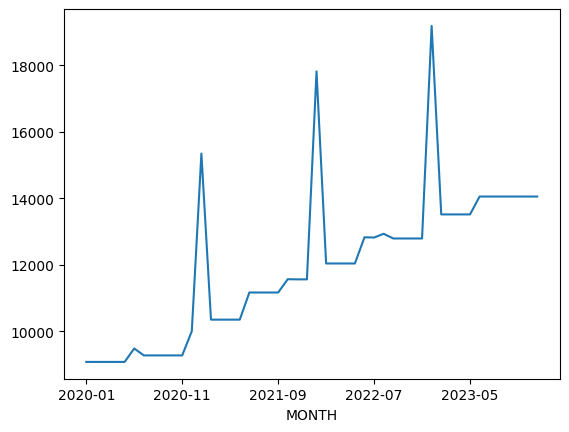

In [27]:
truth_train.groupby("MONTH").size().plot()  

Le graphique confirme la non-stationarite du dataset , ainsi que : 
- une tendance d'opportunite croissante (peut-etre parceque economiquement les reseaux energetique evolue donc de nouveaux EIDs apparaissent, les simulations couvrent plus d'actifs )
- quelques pics saisoniers tres forts (a exploiter )
- une variabilité importante


<Axes: xlabel='MONTH'>

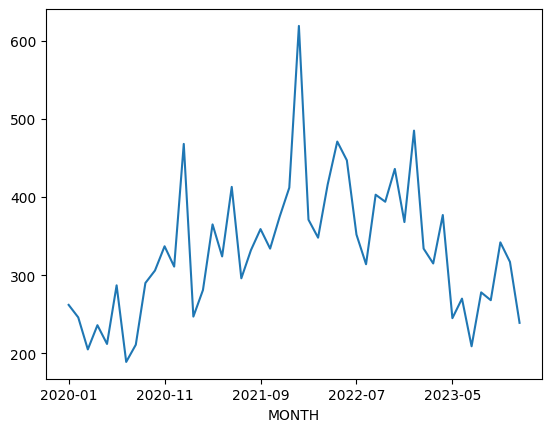

In [28]:
truth_train.groupby("MONTH")["PROFITABLE"].sum().plot()

<Axes: xlabel='MONTH_NUM'>

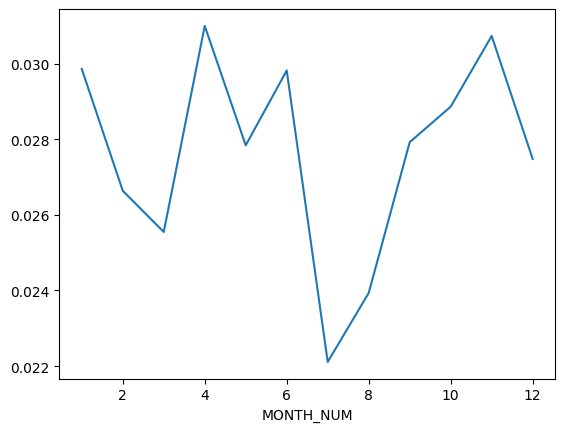

In [29]:
truth_train["MONTH_NUM"] = truth_train["MONTH"].str[5:7].astype(int)
truth_train.groupby("MONTH_NUM")["PROFITABLE"].mean().plot()

Il y a une saisonnalité légère mais réelle.
plus profitable automne/printemps . moins en ete .

## Les simulations prédisent-elles le profit ?

In [30]:
#Construction des features depuis sim_monthly pour resumer les simulations du mois futures
years = [2020, 2021, 2022, 2023]

features = []

for y in years:

    file = DATA_ROOT / "sim_monthly" / f"sim_monthly_{y}.parquet"

    df = duckdb.query(f"""
        SELECT
            EID,
            strftime(DATETIME,'%Y-%m') AS MONTH,
            PEAKID,

            avg(PSM) as m_PSM_mean,
            max(PSM) as m_PSM_max,
            min(PSM) as m_PSM_min,
            stddev_samp(PSM) as m_PSM_std,

            avg(ACTIVATIONLEVEL) as m_ACT_mean,
            max(ACTIVATIONLEVEL) as m_ACT_max,

            avg(WINDIMPACT) as m_WIND_mean,
            avg(LOADIMPACT) as m_LOAD_mean

        FROM read_parquet('{file}')

        GROUP BY 1,2,3
    """).to_df()

    features.append(df)

features_df = pd.concat(features, ignore_index=True)

print(features_df.shape)

(581637, 11)


In [31]:
merged = features_df.merge(
    truth_train,
    on=["EID","MONTH","PEAKID"]
)

print(merged.shape)

(608953, 16)


In [32]:
merged.groupby("PROFITABLE")[["m_PSM_mean","m_ACT_mean"]].mean()

,m_PSM_mean,m_ACT_mean
PROFITABLE,,
False,-0.198306,20.122185
True,-3.033156,33.636248


In [33]:
threshold = merged["m_ACT_mean"].quantile(0.9)

merged[merged["m_ACT_mean"] >= threshold]["PROFITABLE"].mean()

np.float64(0.09099119810825013)

Les opportunite a forte activation sont les plus pofitables . Un saut de 2.7% a 9% => feature puissante 


In [34]:
percentiles = [0.90,0.95,0.98,0.99]

for p in percentiles:
    
    threshold = merged["m_ACT_mean"].quantile(p)
    
    subset = merged[merged["m_ACT_mean"] >= threshold]
    
    print(
        f"Top {100*(1-p):.0f}% activation →",
        subset["PROFITABLE"].mean()
    )


Top 10% activation → 0.09099119810825013


Top 5% activation → 0.12276668418286915
Top 2% activation → 0.17824302134646963
Top 1% activation → 0.2004596946314234


activation ↑ → profitabilité ↑  . Confirmation de l'importance de Activation level


## Certains EID ou PEAKID sont-ils structurellement plus profitables ?

In [35]:
truth_train.groupby("PEAKID")["PROFITABLE"].mean()


PEAKID
0    0.027682
1    0.027716
Name: PROFITABLE, dtype: float64

Pas de difference en terme de profitabilite entre les heures creuses et de pointes

In [36]:
truth_train.groupby("PEAKID").size()


PEAKID
0    296076
1    278535
dtype: int64

In [37]:
eid_perf = truth_train.groupby("EID")["PROFITABLE"].mean()

eid_perf.describe()


count    7394.000000
mean        0.025628
std         0.083341
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: PROFITABLE, dtype: float64

75 % des EID ont une profitabilité moyenne = 0
la majorité des actifs ne génèrent jamais d'opportunité profitable
Donc certains EID ont beaucoup d'opportunités profitables cela cree une distribution asymetrique .

=> interpretation economique : le réseau électrique contient
des zones structurellement intéressantes (peut etre congestion reccurente, contraintes de transmission ....)
 


In [38]:
eid_perf.sort_values(ascending=False).head(20)    # Les EID profitables


EID
7383    1.000000
4768    0.969697
36      0.959596
5573    0.949495
5035    0.868687
6585    0.865169
4922    0.848485
4559    0.808081
6378    0.797980
5273    0.757576
5841    0.747475
5976    0.747475
4588    0.747475
4919    0.737374
5304    0.727273
8002    0.727273
8011    0.727273
4999    0.717172
1947    0.707071
439     0.707071
Name: PROFITABLE, dtype: float64

### Quel type de déséquilibre crée une opportunité

Par exemple :

(Source , potentiel prédictif),(wind ,renouvelable intermittent) ,(solar ,saisonnier) , (hydro , régulé ) , (external ,imports), (nonrenewable ,centrales)

Donc certaines causes peuvent générer des spreads exploitables

In [39]:
features = []

for y in [2020, 2021, 2022, 2023]:
    file = DATA_ROOT / "sim_monthly" / f"sim_monthly_{y}.parquet"

    df = duckdb.query(f"""
        SELECT
            EID,
            strftime(DATETIME,'%Y-%m') AS MONTH,
            PEAKID,

            avg(PSM) as m_PSM_mean,
            max(PSM) as m_PSM_max,
            min(PSM) as m_PSM_min,
            stddev_samp(PSM) as m_PSM_std,

            avg(ACTIVATIONLEVEL) as m_ACT_mean,
            max(ACTIVATIONLEVEL) as m_ACT_max,

            avg(WINDIMPACT) as m_WINDIMPACT_mean,
            avg(SOLARIMPACT) as m_SOLARIMPACT_mean,
            avg(HYDROIMPACT) as m_HYDROIMPACT_mean,
            avg(NONRENEWBALIMPACT) as m_NONRENEWBALIMPACT_mean,
            avg(EXTERNALIMPACT) as m_EXTERNALIMPACT_mean,
            avg(LOADIMPACT) as m_LOADIMPACT_mean,
            avg(TRANSMISSIONOUTAGEIMPACT) as m_TRANSMISSIONOUTAGEIMPACT_mean

        FROM read_parquet('{file}')
        GROUP BY 1,2,3
    """).to_df()

    features.append(df)

features_df = pd.concat(features, ignore_index=True)

merged = features_df.merge(
    truth_train,
    on=["EID", "MONTH", "PEAKID"]
)

In [40]:
df = merged.copy()

# Trier par activation
df = df.sort_values("m_ACT_max", ascending=False)

# profit cumulé
df["cum_profit"] = df["PROFIT"].cumsum()

# fraction des observations
df["fraction"] = range(1, len(df)+1)
df["fraction"] = df["fraction"] / len(df)

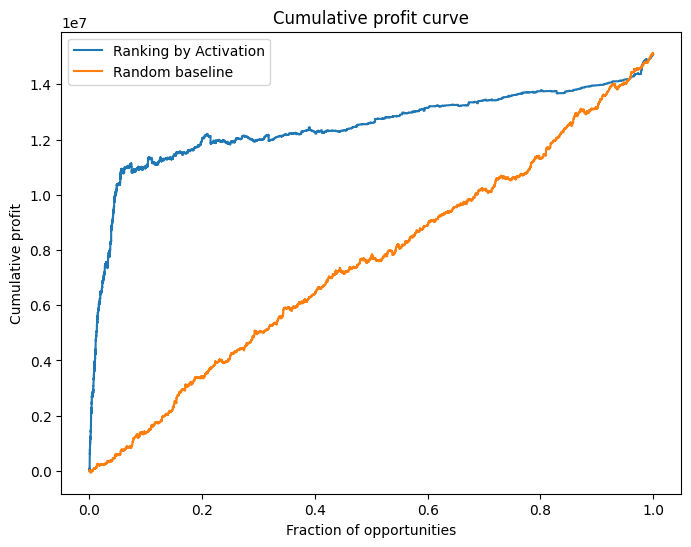

In [41]:

plt.figure(figsize=(8,6))

plt.plot(df["fraction"], df["cum_profit"], label="Ranking by Activation")

# baseline aléatoire
random_profit = df["PROFIT"].sample(frac=1, random_state=42).cumsum()

plt.plot(df["fraction"], random_profit, label="Random baseline")

plt.xlabel("Fraction of opportunities")
plt.ylabel("Cumulative profit")
plt.title("Cumulative profit curve")

plt.legend()
plt.show()

La courbe bleue (ranking par Activation) monte très vite au début. les opportunités avec activation élevée concentrent une grande partie du profit alors que le baseline est presque lineaire

In [42]:
vars_to_test = [
"m_PSM_mean",
"m_PSM_max",
"m_PSM_min",
"m_PSM_std",
"m_WINDIMPACT_mean",
"m_SOLARIMPACT_mean",
"m_HYDROIMPACT_mean",
"m_NONRENEWBALIMPACT_mean",
"m_EXTERNALIMPACT_mean",
"m_LOADIMPACT_mean",
"m_TRANSMISSIONOUTAGEIMPACT_mean"
]

merged.groupby("PROFITABLE")[vars_to_test].mean()

,m_PSM_mean,m_PSM_max,m_PSM_min,m_PSM_std,m_WINDIMPACT_mean,m_SOLARIMPACT_mean,m_HYDROIMPACT_mean,m_NONRENEWBALIMPACT_mean,m_EXTERNALIMPACT_mean,m_LOADIMPACT_mean,m_TRANSMISSIONOUTAGEIMPACT_mean
PROFITABLE,,,,,,,,,,,
False,-0.198306,0.230708,-6.350211,0.694574,9.299881,0.002640,0.994791,7.507396,0.171531,0.167046,-1.345181
True,-3.033156,1.167586,-70.408188,8.594256,15.649901,-0.094725,0.628450,12.048825,0.719534,2.639924,5.468542


opportunité profitable =  activation élevée + prix simulé extrême + déséquilibre production / demande + congestion réseau